# Notebook 5: Resultado y Robustez

**Objetivo:** comparar el rendimiento de la estrategia momentum (con y sin costes
de transacción) contra el benchmark SPY mediante un cuadro completo de métricas
de riesgo-retorno, visualización gráfica y un test de robustez Monte Carlo con
25 millones de agentes aleatorios.

**Inputs (de NB1, NB2 y NB4):**
- `equity_costs.parquet` — equity curve diaria de la estrategia con costes (NB4)
- `equity_no_costs.parquet` — equity curve diaria de la estrategia sin costes (NB4)
- `logs_costs.parquet` — log de operaciones con comisiones (NB4)
- `spy.parquet` — precios del benchmark SPY (NB1)
- `closes.parquet` — precios close de todos los activos (NB1)
- `eligible_universe.parquet` — universo elegible por fecha de rebalanceo (NB2)

**Outputs:**
- Ninguno (notebook de análisis final)

## Bloque 1: Cuadro de métricas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ---------- Rutas ----------
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "practica" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

# ---------- Cargar datos del proyecto ----------
equity_strategy = pd.read_parquet(DATA_DIR / "equity_costs.parquet")["equity"]
equity_no_costs_series = pd.read_parquet(DATA_DIR / "equity_no_costs.parquet")["equity"]
spy_raw = pd.read_parquet(DATA_DIR / "spy.parquet")
spy_close = spy_raw["close"]
closes = pd.read_parquet(DATA_DIR / "closes.parquet")
eligible_universe = pd.read_parquet(DATA_DIR / "eligible_universe.parquet")

# ---------- Retornos diarios ----------
ret_strategy = equity_strategy.pct_change().dropna()
ret_no_costs = equity_no_costs_series.pct_change().dropna()
ret_spy = spy_close.pct_change().dropna()

# Alinear todos a fechas comunes
returns = pd.DataFrame({
    "Estrategia": ret_strategy,
    "Sin Costes": ret_no_costs,
    "SPY": ret_spy,
}).dropna()

# ---------- Retornos acumulados (base 1) ----------
cumulative_returns = (1 + returns).cumprod()

# ---------- Horizonte temporal en años ----------
years = (returns.index[-1] - returns.index[0]).days / 365.25

# Recortar SPY al periodo de backtest
spy_close = spy_close.loc[returns.index[0]:returns.index[-1]]

# ---------- Tasa libre de riesgo (BIL) ----------
bil_data = yf.download(
    "BIL",
    start=returns.index[0].strftime("%Y-%m-%d"),
    end=(returns.index[-1] + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    progress=False,
    auto_adjust=True,
)
if isinstance(bil_data["Close"], pd.DataFrame):
    close_bil = bil_data["Close"].squeeze()
else:
    close_bil = bil_data["Close"]
close_bil.index = close_bil.index.tz_localize(None)

returns_bil = close_bil.pct_change().dropna()
returns_bil = returns_bil.reindex(returns.index).fillna(0)

Rf_annual_bil = (1 + returns_bil).prod() ** (252 / len(returns_bil)) - 1
rf_daily = (1 + Rf_annual_bil) ** (1 / 252) - 1

# ---------- Resumen ----------
tickers = returns.columns.tolist()
print(f"Periodo:  {returns.index[0].date()} → {returns.index[-1].date()} ({years:.1f} años)")
print(f"Observaciones diarias: {len(returns):,}")
print(f"Rf anualizado (BIL):   {Rf_annual_bil:.2%}")
print(f"Rf diario:             {rf_daily:.6f}")
print(f"Closes shape:          {closes.shape}")
print(f"Eligible universe:     {eligible_universe.shape}")

Periodo:  2015-02-02 → 2026-01-30 (11.0 años)
Observaciones diarias: 2,766
Rf anualizado (BIL):   1.87%
Rf diario:             0.000074
Closes shape:          (9087, 1273)
Eligible universe:     (133, 1273)


### CAGR (Tasa de Crecimiento Anual Compuesta)

El **CAGR** (Compound Annual Growth Rate) expresa el retorno como una tasa anual constante equivalente, incorporando el efecto del interés compuesto.

$$\text{CAGR} = \left(\frac{V_{final}}{V_{inicial}}\right)^{\frac{1}{n}} - 1$$

donde $n$ es el número de años.

**Ventaja sobre el Retorno Total**: Permite comparar inversiones con diferentes horizontes temporales. Un CAGR del 10% significa que la inversión creció *como si* hubiera crecido un 10% cada año, de forma compuesta.

**Interpretación**: Un CAGR > tasa de inflación indica que la inversión generó riqueza real.

In [2]:
# --- CAGR ---
cagr = {}
for col in tickers:
    cagr[col] = cumulative_returns[col].iloc[-1] ** (1 / years) - 1

print(f"CAGR (período de {years:.1f} años)")
print("=" * 50)
for col in tickers:
    print(f"   {col:<15} {cagr[col]:.2%}")

print(f"\n   Diferencias vs SPY:")
for col in ['Estrategia', 'Sin Costes']:
    diff = cagr[col] - cagr['SPY']
    print(f"   {col:<15} {diff:+.2%}")
print(f"\n   Drag por costes: {cagr['Estrategia'] - cagr['Sin Costes']:+.2%}")

CAGR (período de 11.0 años)
   Estrategia      9.82%
   Sin Costes      13.19%
   SPY             13.89%

   Diferencias vs SPY:
   Estrategia      -4.07%
   Sin Costes      -0.70%

   Drag por costes: -3.37%


### Volatilidad Anualizada

La **volatilidad** mide la dispersión de los retornos alrededor de su media. Se calcula como la desviación estándar de los retornos diarios, anualizada multiplicando por $\sqrt{252}$ (días de trading al año).

$$\sigma_{anual} = \sigma_{diaria} \times \sqrt{252}$$

**Interpretación**: Una volatilidad del 20% significa que, en un año típico, el retorno puede desviarse ±20% de su media (asumiendo distribución normal, lo cual es una simplificación).

**Limitación importante**: La volatilidad trata igual una subida del 5% que una bajada del 5%. Para un inversor, el riesgo real está en las bajadas, no en las subidas. Por eso usamos también la Downside Deviation.

In [3]:
# --- Volatilidad Anualizada ---
volatility = returns.std() * np.sqrt(252)

print("VOLATILIDAD ANUALIZADA")
print("=" * 50)
for col in tickers:
    print(f"   {col:<15} {volatility[col]:.2%}")

print(f"\n   Diferencias vs SPY:")
for col in ['Estrategia', 'Sin Costes']:
    diff = volatility[col] - volatility['SPY']
    print(f"   {col:<15} {diff:+.2%} ({'mayor' if diff > 0 else 'menor'})")

VOLATILIDAD ANUALIZADA
   Estrategia      25.43%
   Sin Costes      25.37%
   SPY             17.75%

   Diferencias vs SPY:
   Estrategia      +7.67% (mayor)
   Sin Costes      +7.62% (mayor)


### Sharpe Ratio

El **Sharpe Ratio** es el ratio de rendimiento ajustado por riesgo más utilizado en finanzas. Mide el exceso de retorno por unidad de riesgo total (volatilidad).

$$\text{Sharpe} = \frac{R_p - R_f}{\sigma_p}$$

donde $R_p$ es el retorno anualizado de la cartera, $R_f$ la tasa libre de riesgo, y $\sigma_p$ la volatilidad anualizada.

**Interpretación**:
- Sharpe < 0: La inversión rinde menos que el activo libre de riesgo
- 0 < Sharpe < 1: Retorno positivo pero no compensa bien el riesgo
- 1 < Sharpe < 2: Buen rendimiento ajustado por riesgo
- Sharpe > 2: Excelente (raro en estrategias pasivas a largo plazo)

**Limitaciones**:
- Asume distribución normal de retornos (no captura bien el riesgo de cola)
- Penaliza la volatilidad al alza igual que la volatilidad a la baja
- Sensible al período de medición y a la frecuencia de datos

In [4]:
# --- Sharpe Ratio (Rf = BIL) ---
sharpe = {}
for col in tickers:
    excess = returns[col] - rf_daily
    sharpe[col] = excess.mean() / excess.std() * np.sqrt(252)

print(f"SHARPE RATIO (Rf = BIL, {Rf_annual_bil:.2%} anual)")
print("=" * 50)
for col in tickers:
    print(f"   {col:<15} {sharpe[col]:.3f}")

winner = max(sharpe, key=sharpe.get)
print(f"\n   Mejor Sharpe: {winner}")

SHARPE RATIO (Rf = BIL, 1.87% anual)
   Estrategia      0.424
   Sin Costes      0.543
   SPY             0.718

   Mejor Sharpe: SPY


### Sortino Ratio

El **Sortino Ratio** mejora al Sharpe al usar la **downside deviation** en lugar de la volatilidad total como medida de riesgo. Solo penaliza la volatilidad negativa (las pérdidas).

$$\text{Sortino} = \frac{R_p - R_f}{\sigma_{down}}$$

**¿Cuándo preferir el Sortino al Sharpe?**
- Cuando la distribución de retornos es asimétrica (skewness ≠ 0)
- Cuando nos preocupa más el riesgo de pérdida que la volatilidad general
- En comparaciones de estrategias con diferentes perfiles de asimetría

**Interpretación**: Un Sortino > Sharpe indica que una proporción significativa de la volatilidad viene de movimientos al alza (lo cual es positivo). Si Sortino ≈ Sharpe, la volatilidad es simétrica.

In [5]:
# --- Sortino Ratio (Rf = BIL) ---
sortino = {}
for col in tickers:
    excess = returns[col] - rf_daily
    downside = excess.copy()
    downside[downside > 0] = 0
    downside_dev = np.sqrt((downside ** 2).mean()) * np.sqrt(252)
    sortino[col] = (excess.mean() * 252) / downside_dev

print(f"SORTINO RATIO (Rf = BIL, {Rf_annual_bil:.2%} anual)")
print("=" * 50)
for col in tickers:
    print(f"   {col:<15} {sortino[col]:.3f}")

print(f"\nComparación Sortino vs Sharpe:")
for col in tickers:
    diff = sortino[col] - sharpe[col]
    print(f"   {col:<15} Sortino = {sortino[col]:.3f} vs Sharpe = {sharpe[col]:.3f} (dif: {diff:+.3f})")
print(f"\n   Sortino > Sharpe indica que la volatilidad bajista es menor que la total.")

SORTINO RATIO (Rf = BIL, 1.87% anual)
   Estrategia      0.585
   Sin Costes      0.752
   SPY             1.007

Comparación Sortino vs Sharpe:
   Estrategia      Sortino = 0.585 vs Sharpe = 0.424 (dif: +0.161)
   Sin Costes      Sortino = 0.752 vs Sharpe = 0.543 (dif: +0.209)
   SPY             Sortino = 1.007 vs Sharpe = 0.718 (dif: +0.289)

   Sortino > Sharpe indica que la volatilidad bajista es menor que la total.


### Maximum Drawdown

El **Maximum Drawdown** (Máximo Drawdown) mide la mayor caída desde un máximo histórico hasta el siguiente mínimo. Representa el **peor escenario** que habría experimentado un inversor.

$$\text{Drawdown}(t) = \frac{V(t) - V_{max}(t)}{V_{max}(t)}$$

$$\text{Max Drawdown} = \min_{t} \text{Drawdown}(t)$$

**Interpretación**: Un Max Drawdown del -34% significa que, en el peor momento, la inversión perdió un 34% desde su último máximo. Es una métrica crucial para la psicología del inversor: muchos abandonan sus estrategias durante drawdowns profundos, realizando las pérdidas.

**Nota**: El Max Drawdown siempre es un valor negativo (o cero).

In [6]:
# --- Maximum Drawdown ---
def calculate_drawdown_series(cum_returns_series):
    """Calcula la serie de drawdown a partir de retornos acumulados."""
    rolling_max = cum_returns_series.cummax()
    return (cum_returns_series - rolling_max) / rolling_max

drawdowns = pd.DataFrame()
for col in tickers:
    drawdowns[col] = calculate_drawdown_series(cumulative_returns[col])

max_drawdown = drawdowns.min()

print("MAXIMUM DRAWDOWN")
print("=" * 50)
for col in tickers:
    dd_date = drawdowns[col].idxmin()
    peak_date = cumulative_returns[col][:dd_date].idxmax()
    print(f"   {col:<15} {max_drawdown[col]:.2%}  (pico: {peak_date.date()}, valle: {dd_date.date()})")

print(f"\n   Diferencias vs SPY:")
for col in ['Estrategia', 'Sin Costes']:
    diff = abs(max_drawdown[col]) - abs(max_drawdown['SPY'])
    print(f"   {col:<15} {diff:+.2%} ({'más profundo' if diff > 0 else 'menos profundo'})")

MAXIMUM DRAWDOWN
   Estrategia      -45.83%  (pico: 2018-09-04, valle: 2020-03-23)
   Sin Costes      -42.86%  (pico: 2018-09-04, valle: 2020-03-23)
   SPY             -33.72%  (pico: 2020-02-19, valle: 2020-03-23)

   Diferencias vs SPY:
   Estrategia      +12.11% (más profundo)
   Sin Costes      +9.14% (más profundo)


A continuación, visualizamos la evolución del drawdown para comparar la profundidad y duración de las caídas entre las estrategias y el benchmark.

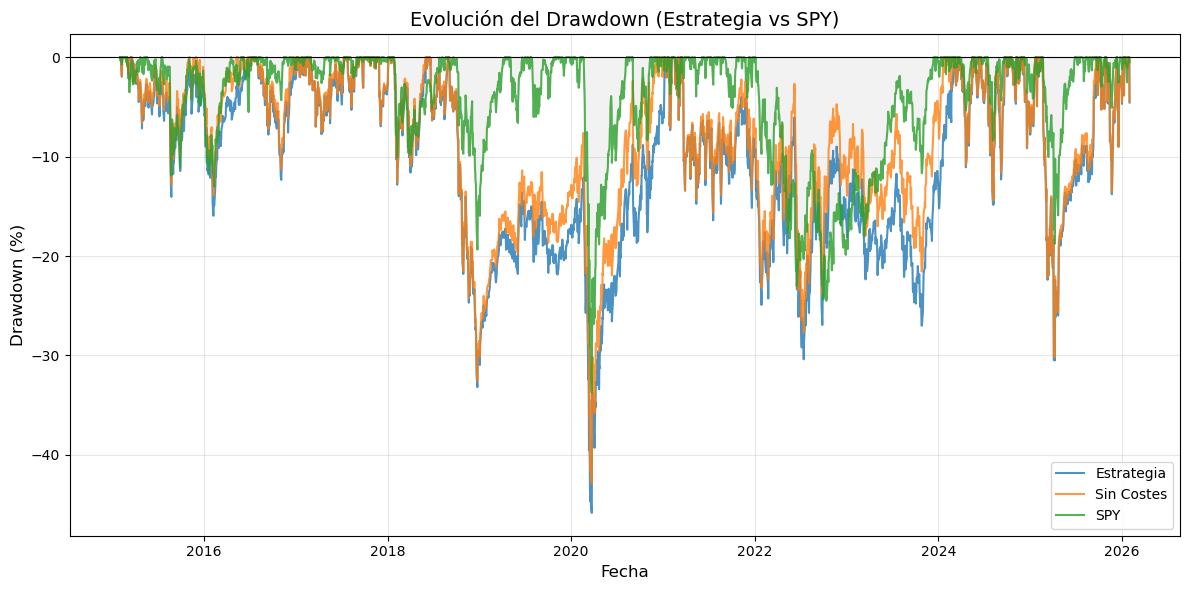

In [7]:
# --- Gráfico de Evolución del Drawdown ---
plt.figure(figsize=(12, 6))
for col in tickers:
    plt.plot(drawdowns.index, drawdowns[col] * 100, label=col, alpha=0.8, linewidth=1.5)

plt.fill_between(drawdowns.index, drawdowns['SPY'] * 100, 0, alpha=0.1, color='gray')
plt.title('Evolución del Drawdown (Estrategia vs SPY)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Drawdown (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


El análisis del drawdown evidencia la vulnerabilidad de la estrategia de Momentum ante shocks sistémicos, alcanzando su punto de mayor estrés en marzo de 2020 con una caída máxima del -45.83%, cifra que supera significativamente el -33.72% experimentado por el SPY. Esta brecha de 12 puntos porcentuales subraya la naturaleza agresiva del modelo, cuya Beta de 1.11 y su concentración en sectores de alto crecimiento y semiconductores amplifican las pérdidas durante rotaciones bruscas del mercado. Asimismo, la persistente separación entre la curva real y la teórica sin costes demuestra que la estructura de comisiones fijas no solo profundiza estas caídas, sino que actúa como un lastre operativo que retrasa sistemáticamente la recuperación de los máximos históricos (periodo underwater), exigiendo una rentabilidad de casi el 84% para restaurar el capital tras el peor escenario y comprometiendo la robustez del sistema en entornos de pánico financiero.

### Alpha de Jensen

El **Alpha de Jensen** mide el retorno adicional que genera MTUM **una vez descontada su exposición al mercado** (beta). Es el intercepto de la regresión CAPM.

$$\alpha = (R_{MTUM} - R_f) - \beta \times (R_{SPY} - R_f)$$

**Interpretación**:
- α > 0: MTUM genera valor por encima de lo que su beta justificaría (el factor momentum añade valor)
- α = 0: MTUM se comporta exactamente como predice el CAPM (no hay valor añadido)
- α < 0: MTUM destruye valor respecto a lo que su beta justificaría

**Significancia estadística**: Es crucial verificar el p-valor del alpha. Si p > 0.05, no podemos rechazar la hipótesis nula de que α = 0, es decir, no podemos afirmar con confianza que el alpha sea diferente de cero.

**Nota técnica**: `scipy.stats.linregress` devuelve el p-valor asociado al **slope** (pendiente/beta), NO al intercepto (alpha). Para obtener el p-valor del alpha, es necesario calcular el t-estadístico usando `result.intercept_stderr` (disponible desde scipy >= 1.7) y la distribución t de Student con n-2 grados de libertad. Este es un error común en muchos tutoriales.

In [8]:
# --- Alpha de Jensen (Regresión CAPM) ---
from scipy.stats import linregress
from scipy.stats import t as t_dist

def compute_capm(returns_port, returns_mkt, rf_daily, label):
    """Calcula regresión CAPM y devuelve dict con resultados."""
    excess_port = returns_port - rf_daily
    excess_mkt = returns_mkt - rf_daily
    result = linregress(excess_mkt, excess_port)

    n = len(excess_mkt)
    alpha_daily = result.intercept
    alpha_annual = (1 + alpha_daily) ** 252 - 1
    r2 = result.rvalue ** 2
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - 2)

    t_stat_a = alpha_daily / result.intercept_stderr
    p_alpha = 2 * (1 - t_dist.cdf(abs(t_stat_a), df=n - 2))

    return {
        'label': label, 'beta': result.slope, 'alpha_daily': alpha_daily,
        'alpha_annual': alpha_annual, 'r2': r2, 'r2_adj': r2_adj,
        'p_alpha': p_alpha, 't_alpha': t_stat_a,
        'stderr_alpha': result.intercept_stderr,
        'p_beta': result.pvalue, 'stderr_beta': result.stderr, 'n': n,
    }

# Calcular para ambas versiones de la estrategia
capm_results = {}
for col in ['Estrategia', 'Sin Costes']:
    capm_results[col] = compute_capm(returns[col], returns['SPY'], rf_daily, col)

n_obs = capm_results['Estrategia']['n']

print("REGRESIÓN CAPM: R_portfolio - Rf = α + β × (R_SPY - Rf)")
print(f"   (Rf = BIL, {Rf_annual_bil:.2%} anual | {n_obs} obs. diarias)")
print("=" * 70)

for col in ['Estrategia', 'Sin Costes']:
    r = capm_results[col]
    sig_a = '✓' if r['p_alpha'] < 0.05 else '✗'
    sig_b = '✓' if r['p_beta'] < 0.05 else '✗'
    print(f"\n   [{r['label']}]")
    print(f"      Alpha anual:  {r['alpha_annual']:>+8.2%}  (t={r['t_alpha']:+.3f}, p={r['p_alpha']:.4f} {sig_a})")
    print(f"      Beta:         {r['beta']:>8.4f}  (p={r['p_beta']:.2e} {sig_b})")
    print(f"      R²:           {r['r2']:>8.4f}  ({r['r2']:.1%} varianza explicada)")

# Guardar para la celda de Beta
beta_capm = capm_results['Estrategia']['beta']
alpha_annual = capm_results['Estrategia']['alpha_annual']
r_squared = capm_results['Estrategia']['r2']
r_squared_adj = capm_results['Estrategia']['r2_adj']

REGRESIÓN CAPM: R_portfolio - Rf = α + β × (R_SPY - Rf)
   (Rf = BIL, 1.87% anual | 2766 obs. diarias)

   [Estrategia]
      Alpha anual:    -3.43%  (t=-0.728, p=0.4664 ✗)
      Beta:           1.1187  (p=0.00e+00 ✓)
      R²:             0.6102  (61.0% varianza explicada)

   [Sin Costes]
      Alpha anual:    -0.45%  (t=-0.093, p=0.9257 ✗)
      Beta:           1.1159  (p=0.00e+00 ✓)
      R²:             0.6097  (61.0% varianza explicada)


### Beta

El **Beta** mide la sensibilidad de MTUM a los movimientos del mercado (SPY). Se calcula como:

$$\hat{\beta} = \frac{\widehat{\text{Cov}}(R_{MTUM}, R_{SPY})}{\widehat{\text{Var}}(R_{SPY})}$$

donde $\hat{}$ indica que se usan estimadores muestrales calculados a partir de los datos observados.

**Interpretación**:
- β = 1: MTUM se mueve exactamente igual que el mercado
- β > 1: MTUM amplifica los movimientos del mercado (más volátil, más agresivo)
- β < 1: MTUM amortigua los movimientos del mercado (más defensivo)
- β < 0: MTUM se mueve en dirección opuesta al mercado (muy raro para un ETF de renta variable)

**R² (R-squared)**: Indica qué porcentaje de los movimientos de MTUM se explican por los movimientos de SPY. Un R² de 0.90 significa que el 90% de la variabilidad de MTUM viene del mercado, y solo el 10% es específico del factor momentum. El **R² ajustado** corrige por el número de predictores, aunque en regresión simple la diferencia es mínima.

In [9]:
# --- Beta y R-squared ---
print("BETA Y R-SQUARED")
print("=" * 70)
print(f"   {'Métrica':<25} {'Estrategia':>12} {'Sin Costes':>12} {'SPY':>10}")
print(f"   {'-'*25} {'-'*12} {'-'*12} {'-'*10}")

r_e = capm_results['Estrategia']
r_nc = capm_results['Sin Costes']
print(f"   {'Beta':<25} {r_e['beta']:>12.4f} {r_nc['beta']:>12.4f} {'1.0000':>10}")
print(f"   {'R-squared':<25} {r_e['r2']:>12.4f} {r_nc['r2']:>12.4f} {'1.0000':>10}")
print(f"   {'R-squared ajustado':<25} {r_e['r2_adj']:>12.4f} {r_nc['r2_adj']:>12.4f} {'1.0000':>10}")

print(f"\n   Interpretación Beta Estrategia = {r_e['beta']:.3f}:")
if r_e['beta'] > 1.05:
    print(f"   La estrategia es más agresiva que el mercado: cuando SPY sube 1%, sube ~{r_e['beta']:.2f}%")
    print(f"   Pero también cae más: cuando SPY baja 1%, baja ~{r_e['beta']:.2f}%")
elif r_e['beta'] < 0.95:
    print(f"   La estrategia es más defensiva que el mercado.")
else:
    print(f"   La estrategia tiene un beta cercano a 1, se mueve de forma similar al mercado.")

BETA Y R-SQUARED
   Métrica                     Estrategia   Sin Costes        SPY
   ------------------------- ------------ ------------ ----------
   Beta                            1.1187       1.1159     1.0000
   R-squared                       0.6102       0.6097     1.0000
   R-squared ajustado              0.6100       0.6096     1.0000

   Interpretación Beta Estrategia = 1.119:
   La estrategia es más agresiva que el mercado: cuando SPY sube 1%, sube ~1.12%
   Pero también cae más: cuando SPY baja 1%, baja ~1.12%


### Cuadro Resumen de Métricas

A continuación, se presenta un cuadro consolidado que resume todas las métricas calculadas para la estrategia con y sin costes, así como para el benchmark SPY.

In [10]:
# --- Cuadro Resumen ---
summary_df = pd.DataFrame({
    'Métrica': ['CAGR', 'Volatilidad Anual', 'Sharpe Ratio', 'Sortino Ratio', 'Max Drawdown', 'Alpha de Jensen', 'Beta'],
    'Estrategia': [
        f"{cagr['Estrategia']:.2%}",
        f"{volatility['Estrategia']:.2%}",
        f"{sharpe['Estrategia']:.3f}",
        f"{sortino['Estrategia']:.3f}",
        f"{max_drawdown['Estrategia']:.2%}",
        f"{capm_results['Estrategia']['alpha_annual']:.2%}",
        f"{capm_results['Estrategia']['beta']:.4f}"
    ],
    'Sin Costes': [
        f"{cagr['Sin Costes']:.2%}",
        f"{volatility['Sin Costes']:.2%}",
        f"{sharpe['Sin Costes']:.3f}",
        f"{sortino['Sin Costes']:.3f}",
        f"{max_drawdown['Sin Costes']:.2%}",
        f"{capm_results['Sin Costes']['alpha_annual']:.2%}",
        f"{capm_results['Sin Costes']['beta']:.4f}"
    ],
    'SPY': [
        f"{cagr['SPY']:.2%}",
        f"{volatility['SPY']:.2%}",
        f"{sharpe['SPY']:.3f}",
        f"{sortino['SPY']:.3f}",
        f"{max_drawdown['SPY']:.2%}",
        "-",
        "1.0000"
    ]
}).set_index('Métrica')

display(summary_df)

,Estrategia,Sin Costes,SPY
Métrica,,,
CAGR,9.82%,13.19%,13.89%
Volatilidad Anual,25.43%,25.37%,17.75%
Sharpe Ratio,0.424,0.543,0.718
Sortino Ratio,0.585,0.752,1.007
Max Drawdown,-45.83%,-42.86%,-33.72%
Alpha de Jensen,-3.43%,-0.45%,-
Beta,1.1187,1.1159,1.0000


### Análisis de Métricas: Estrategia vs. Benchmark

La tabla comparativa revela la realidad operativa de la estrategia de Momentum frente al mercado (SPY) y el impacto crítico de los costes transaccionales.

#### 1. El Impacto de los Costes
Es el hallazgo más relevante del estudio. El **CAGR** cae de un **13.19%** (Sin Costes) a un **9.82%** (Estrategia Real). 
* Perder más de **3 puntos porcentuales de rentabilidad anual** se debe directamente a la estructura de comisiones: un 0.23% de variable con un **mínimo de 23$ por orden**. 
* En una cartera de 20 activos con un turnover medio de 7 entradas/salidas mensuales, este mínimo penaliza desproporcionadamente los rebalanceos mensuales, especialmente en activos cuyo peso apenas ha variado pero que el algoritmo obliga a ajustar para mantener el 5% estricto. 

#### 2. Rendimiento Relativo y Alpha
* **Underperformance:** El SPY bate a la estrategia en retorno absoluto (**13.89% vs 9.82%**). 
* **Alpha de Jensen (-3.43%):** Al ser negativa, confirma que la estrategia no solo rinde menos que el mercado, sino que no logra generar retornos excedentes para el nivel de riesgo asumido. El mercado ha sido un "rival difícil" en este periodo.

#### 3. Perfil de Riesgo y Volatilidad
* **Beta (1.11):** Indica que nuestra cartera es un **11% más volátil** que el mercado. Somos más sensibles a los movimientos del SPY, amplificando tanto las subidas como las caídas.
* **Máximo Drawdown:** La estrategia sufre una caída máxima del **-45.83%**, significativamente superior al **-33.72%** del SPY. Esto refleja la vulnerabilidad intrínseca del Momentum durante las rotaciones sectoriales o correcciones bruscas del mercado.
* **Eficiencia (Sharpe 0.424 vs 0.718):** El ratio de Sharpe del SPY es casi el doble, lo que demuestra que la inversión pasiva en el índice ha sido mucho más eficiente en términos de retorno por unidad de riesgo durante el periodo analizado.

> **Conclusión técnica:** Aunque la lógica de Momentum es sólida en teoría, la implementación con rebalanceo mensual y comisiones mínimas de 23$ genera una erosión de capital que impide batir al benchmark. La estrategia se comporta como un vehículo de "Beta alta" con una carga operativa que drena el Alpha potencial.

## Bloque 2: Visualización

En esta sección representamos gráficamente los resultados de la comparación del algoritmo de momentum vs SPY.

---


### Grafico 1: Equity Curve (Curva de Rentabilidad Acumulada)

Comparamos la evolucion del valor de la cartera de la estrategia momentum
(con y sin costes) contra el benchmark SPY. Todas las curvas parten de
base 100.

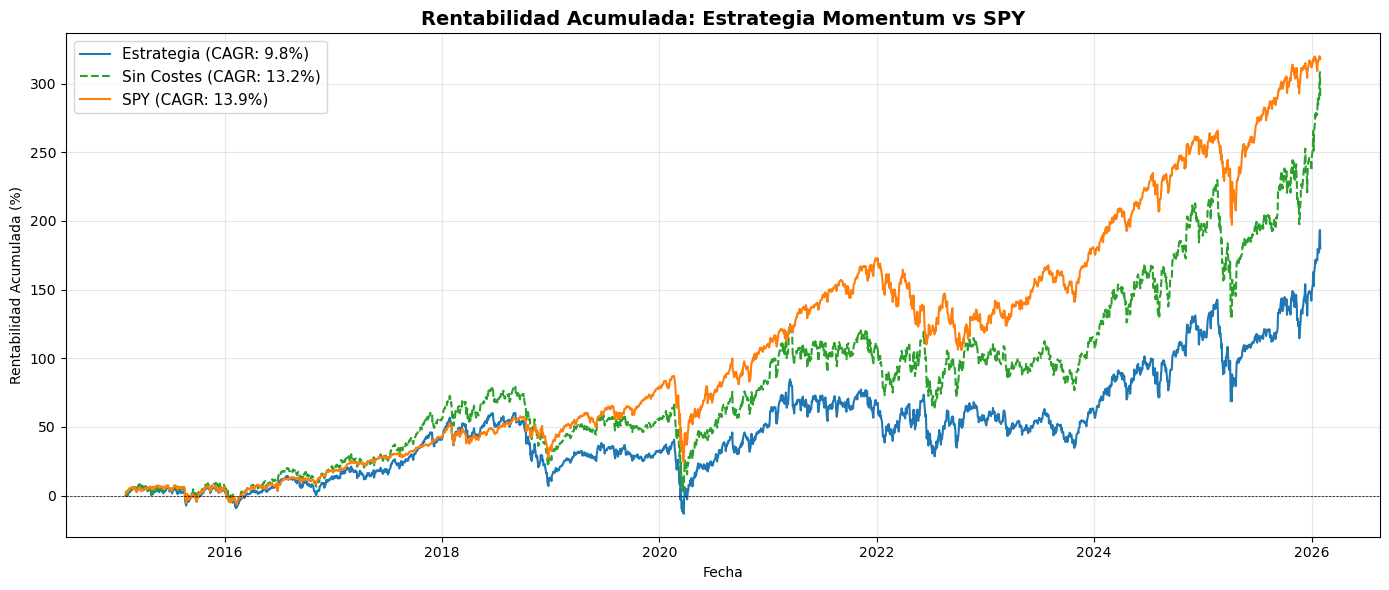

In [11]:
# --- Gráfico 1: Equity Curve (Rentabilidad Acumulada %) ---
fig, ax = plt.subplots(figsize=(14, 6))

cum_pct = (cumulative_returns - 1) * 100

ax.plot(cum_pct.index, cum_pct['Estrategia'],
        label=f'Estrategia (CAGR: {cagr["Estrategia"]:.1%})',
        linewidth=1.5, color='#1f77b4')
ax.plot(cum_pct.index, cum_pct['Sin Costes'],
        label=f'Sin Costes (CAGR: {cagr["Sin Costes"]:.1%})',
        linewidth=1.5, color='#2ca02c', linestyle='--')
ax.plot(cum_pct.index, cum_pct['SPY'],
        label=f'SPY (CAGR: {cagr["SPY"]:.1%})',
        linewidth=1.5, color='#ff7f0e')

ax.set_title('Rentabilidad Acumulada: Estrategia Momentum vs SPY', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Rentabilidad Acumulada (%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

La estrategia momentum con costes (CAGR 9.8%) no consigue superar al benchmark SPY (CAGR 13.9%), mientras que la versión sin costes (CAGR 13.2%) se aproxima pero tampoco lo bate. Esto evidencia que los costes de transacción erosionan aproximadamente 3.4 puntos porcentuales anuales de rentabilidad. Las tres curvas evolucionan de forma similar hasta 2020, momento a partir del cual la estrategia se rezaga especialmente en las fases de recuperación post-crisis.

### Grafico 2: Histograma de Retornos Mensuales

Distribucion de frecuencias de los retornos mensuales de la estrategia
y el benchmark. Permite comparar la forma de la distribucion (asimetria,
curtosis) y la dispersion de ambas series.

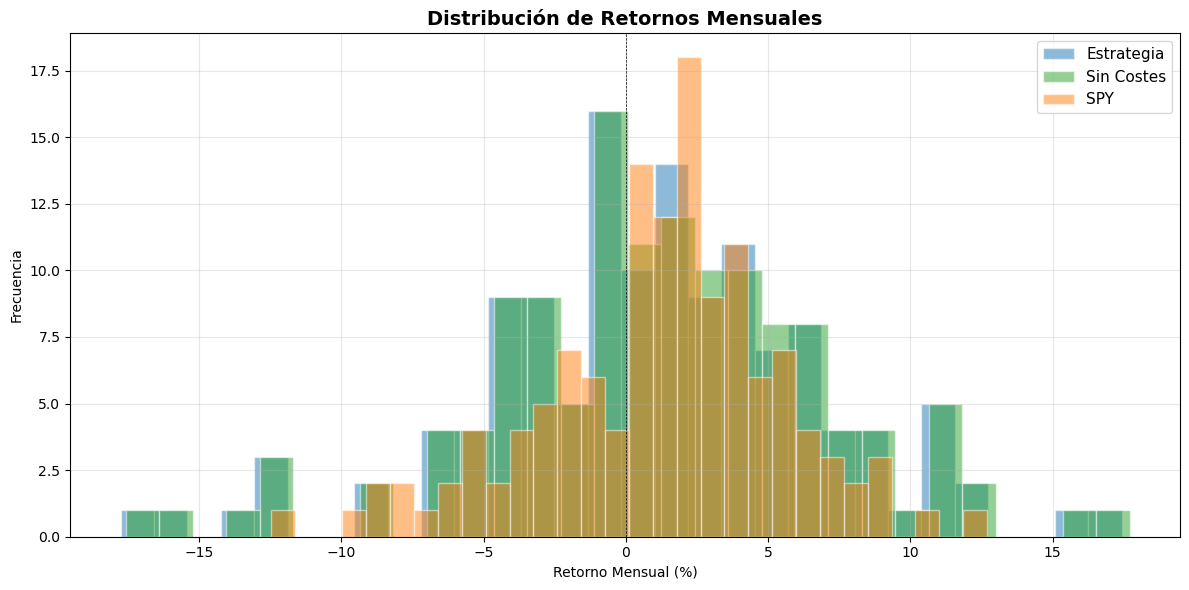

In [12]:
# --- Gráfico 2: Histograma de Retornos Mensuales ---
monthly_returns = returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)

fig, ax = plt.subplots(figsize=(12, 6))

colors = {'Estrategia': '#1f77b4', 'Sin Costes': '#2ca02c', 'SPY': '#ff7f0e'}
for col in tickers:
    ax.hist(monthly_returns[col] * 100, bins=30, alpha=0.5,
            label=col, color=colors[col], edgecolor='white')

ax.set_title('Distribución de Retornos Mensuales', fontsize=14, fontweight='bold')
ax.set_xlabel('Retorno Mensual (%)')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

Las tres distribuciones presentan formas similares, con la estrategia mostrando una concentración ligeramente mayor en retornos cercanos a cero y colas comparables al SPY. La dispersión de la estrategia es similar a la del benchmark, lo que indica que el factor momentum no reduce la volatilidad mensual de forma significativa respecto a una inversión pasiva en el índice.

### Grafico 3: Scatter de Retornos Logaritmicos Anuales

Retornos logaritmicos anuales de la estrategia vs SPY. Cada punto
representa un año. La diagonal indica correlacion perfecta; puntos
por encima significan que la estrategia supero al benchmark ese año.

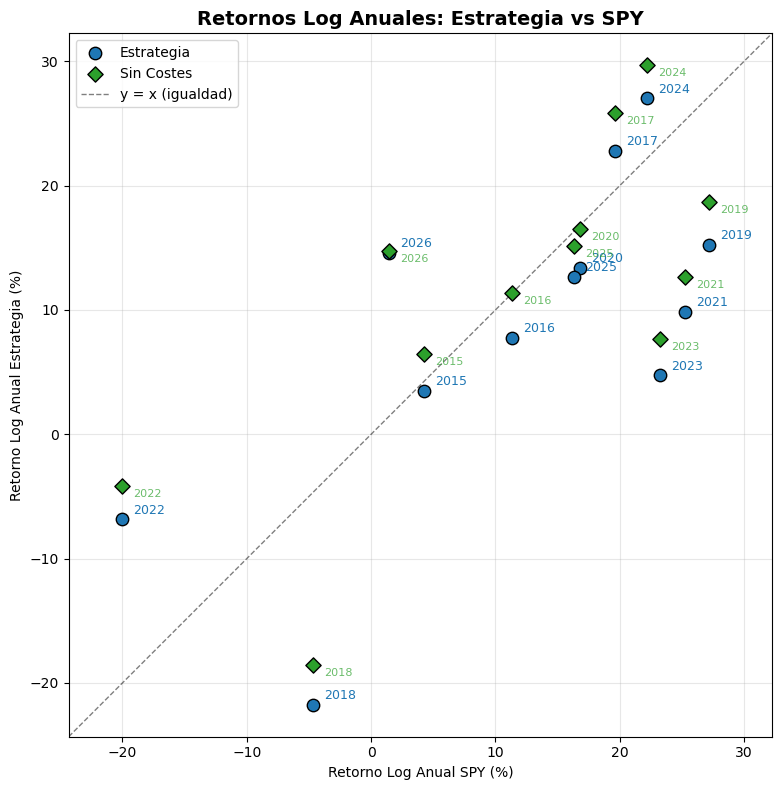

In [13]:
# --- Gráfico 3: Scatter de Retornos Logarítmicos Anuales ---
yearly_returns = returns.resample('YE').apply(lambda x: np.log1p(x).sum()) * 100

fig, ax = plt.subplots(figsize=(8, 8))

# Estrategia (con costes)
ax.scatter(yearly_returns['SPY'], yearly_returns['Estrategia'],
           s=80, color='#1f77b4', edgecolors='black', zorder=3, label='Estrategia')
for idx, row in yearly_returns.iterrows():
    ax.annotate(str(idx.year), (row['SPY'], row['Estrategia']),
                textcoords="offset points", xytext=(8, 4), fontsize=9, color='#1f77b4')

# Sin Costes
ax.scatter(yearly_returns['SPY'], yearly_returns['Sin Costes'],
           s=60, color='#2ca02c', edgecolors='black', zorder=3, marker='D', label='Sin Costes')
for idx, row in yearly_returns.iterrows():
    ax.annotate(str(idx.year), (row['SPY'], row['Sin Costes']),
                textcoords="offset points", xytext=(8, -8), fontsize=8, color='#2ca02c', alpha=0.7)

# Línea de 45° (y = x)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='y = x (igualdad)')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_title('Retornos Log Anuales: Estrategia vs SPY', fontsize=14, fontweight='bold')
ax.set_xlabel('Retorno Log Anual SPY (%)')
ax.set_ylabel('Retorno Log Anual Estrategia (%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

La mayoría de los puntos se sitúan por debajo de la diagonal y=x, confirmando que la estrategia subrinde al SPY en la mayoría de los años. El año 2018 destaca como el peor en términos relativos, mientras que 2017 y 2024 fueron los más favorables para la estrategia. La versión sin costes se aproxima más a la diagonal pero tampoco consigue batir al benchmark de forma consistente.

### Grafico 4: Scatter de Retornos Logaritmicos Trimestrales

Mismo analisis que el grafico anterior pero con frecuencia trimestral,
proporcionando mas puntos de datos para evaluar la consistencia de la
estrategia frente al benchmark.

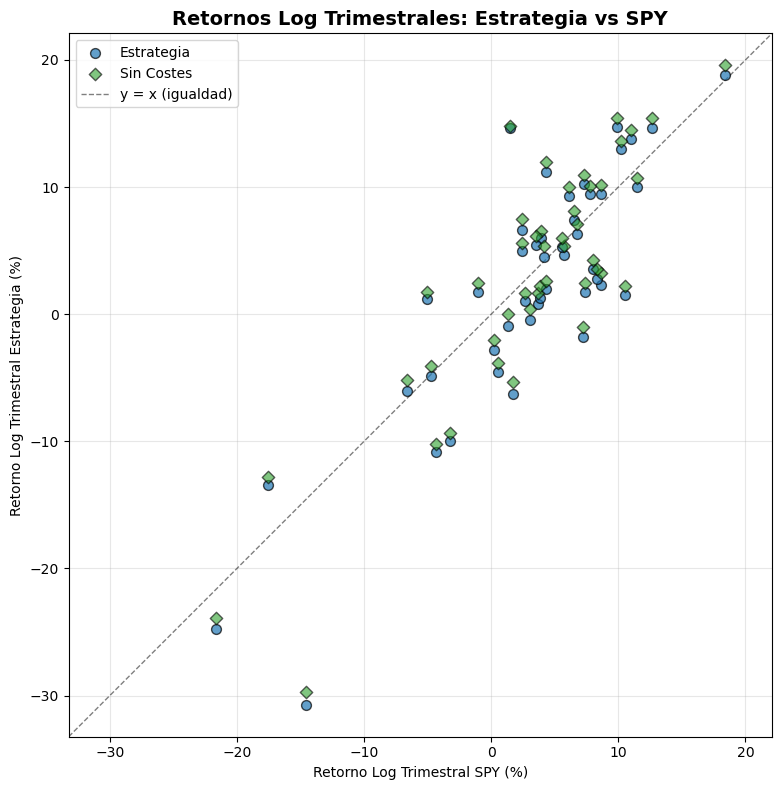

In [14]:
# --- Gráfico 4: Scatter de Retornos Logarítmicos Trimestrales ---
quarterly_returns = returns.resample('QE').apply(lambda x: np.log1p(x).sum()) * 100

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(quarterly_returns['SPY'], quarterly_returns['Estrategia'],
           s=50, color='#1f77b4', alpha=0.7, edgecolors='black', zorder=3, label='Estrategia')
ax.scatter(quarterly_returns['SPY'], quarterly_returns['Sin Costes'],
           s=40, color='#2ca02c', alpha=0.6, edgecolors='black', zorder=3, marker='D', label='Sin Costes')

# Línea de 45° (y = x)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=1, label='y = x (igualdad)')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_title('Retornos Log Trimestrales: Estrategia vs SPY', fontsize=14, fontweight='bold')
ax.set_xlabel('Retorno Log Trimestral SPY (%)')
ax.set_ylabel('Retorno Log Trimestral Estrategia (%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Con mayor granularidad trimestral, se confirma el patrón observado en el gráfico anual: la nube de puntos se concentra ligeramente por debajo de la diagonal y=x, indicando un underperformance sistemático de la estrategia. En trimestres de fuertes caídas (como Q1 2020), la estrategia sufre pérdidas comparables o superiores al mercado, mientras que en trimestres positivos no captura plenamente las subidas del SPY.

## Bloque 3: Monte Carlo

En este bloque comparamos el algoritmo con 25 millones de agentes aleatorios.

En este caso los agentes van a tener un coste fijo de 0,23% por operación de compra y de venta. Además como al final de cada periodo de rebalanceo se compra y  vende el 100% de activos sin tener en cuenta el mínimo de 23 dólares, se incurrirá en un coste de 0,46% por rebalanceo (compra + venta). Esto es una simplificación, pero facilita el cálculo matricial.



### Formulación matemática y programación vectorial

#### Notación

| Símbolo | Descripción | Dimensiones |
|:---|:---|:---|
| $T$ | Períodos de rebalanceo | $133$ |
| $A$ | Activos en el universo | $1{,}273$ |
| $M$ | Monos (simulaciones) | $25{,}000{,}000$ |
| $k$ | Activos por mono | $20$ |
| $\mathbf{R}$ | Matriz de retornos mensuales | $T \times A$ |
| $E_t$ | Activos elegibles en el mes $t$ | $|E_t| \approx 500$ |

#### Paso 1: Selección aleatoria

Cada mono selecciona $k = 20$ activos al azar del pool elegible $E_t$, generando una matriz de índices $\mathbf{I}_t \in \{0, \dots, n_t - 1\}^{M \times k}$ mediante `rng.integers`. Los retornos se extraen por *fancy indexing*:

$$\mathbf{X}_t = \mathbf{r}_t[\mathbf{I}_t] \quad \in \mathbb{R}^{M \times k}$$

#### Paso 2: Retorno equal-weight

El retorno de cada mono es la media de sus $k$ activos:

$$\bar{r}_{t,m} = \frac{1}{k} \sum_{j=1}^{k} X_{t,m,j}$$

En NumPy: `ret_mono = rets_mes[idx].mean(axis=1)` $\;\rightarrow\;$ vector de forma $(M,)$.

> **Nota sobre memoria:** la alternativa matricial $\mathbf{S}_t \cdot \mathbf{r}_t$ requeriría aproximadamente 47 GB. El *fancy indexing* materializa únicamente las $k$ columnas relevantes por mono (aproximadamente 9 GB).

#### Paso 3: Acumulación compuesta con costes

El valor de cada mono se actualiza multiplicativamente aplicando un coste plano $c = 0.46\%$ por rebalanceo:

$$V_{t,m} = V_{t-1,m} \cdot (1 + \bar{r}_{t,m}) \cdot (1 - c)$$

En NumPy: `acumulador *= (1 + ret_mono) * coste`, operación *element-wise* sobre los $M$ monos.

#### Complejidad computacional

| Operación | Sin vectorizar | Vectorizado (NumPy) |
|:---|:---|:---|
| Selección | $O(M \cdot k)$ iteraciones Python | `rng.integers` (C interno) |
| Retorno | Bucle sobre $M$ | `.mean(axis=1)` (BLAS) |
| Acumulación | Bucle sobre $M$ | `*=` *element-wise* |
| **Total** | $T \times M \times k$ operaciones Python | **Solo $T = 133$ iteraciones** |

El único bucle Python es sobre los $T$ meses, necesario porque el universo elegible varía en cada período. Dentro de cada iteración, los 25 millones de monos se procesan de forma completamente vectorizada.

In [15]:
import numpy as np
import pandas as pd
import time

# ═══════════════════════════════════════════════════════════════════════════════
# 1. PREPARACIÓN DE DATOS PARA MONTE CARLO
# ═══════════════════════════════════════════════════════════════════════════════

rebalance_dates = eligible_universe.index  # 133 fechas de rebalanceo

# Precios close en fechas de rebalanceo
closes_at_reb = closes.reindex(rebalance_dates)

# Precio del mes anterior al primer rebalanceo (necesario para el primer retorno)
prev_date = closes.index[closes.index < rebalance_dates[0]][-1]
closes_with_prev = pd.concat([closes.loc[[prev_date]], closes_at_reb])

# Retornos mensuales simples de todos los activos: (T, A)
monthly_rets = closes_with_prev.pct_change().iloc[1:]
monthly_returns_mc = monthly_rets.values.astype(np.float32)

print(f"monthly_returns shape: {monthly_returns_mc.shape}")
print(f"Rango fechas: {rebalance_dates[0].date()} → {rebalance_dates[-1].date()}")

# Índices de activos elegibles por mes (elegible AND retorno válido)
eligible_mask = eligible_universe.values.astype(bool)
eligible_indices = []
for t in range(len(rebalance_dates)):
    valid = eligible_mask[t] & ~np.isnan(monthly_returns_mc[t])
    eligible_indices.append(np.where(valid)[0])

print(f"Elegibles por mes: min={min(len(e) for e in eligible_indices)}, "
      f"max={max(len(e) for e in eligible_indices)}, "
      f"media={np.mean([len(e) for e in eligible_indices]):.0f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 2. SIMULACIÓN MONTE CARLO — 25M MONOS CON DECILES EN CADA PASO
# ═══════════════════════════════════════════════════════════════════════════════

N_MONOS = 25_000_000
N_SEL = 20
N_PERIODS = len(rebalance_dates)
N_YEARS = (rebalance_dates[-1] - rebalance_dates[0]).days / 365.25

coste = np.float32(1 - 0.0046)  # 0.23% compra + 0.23% venta
rng = np.random.default_rng(42)

acumulador = np.ones(N_MONOS, dtype=np.float32)

# Deciles: guardamos percentiles 10, 20, ..., 90 del acumulador en cada paso
decile_pcts = [10, 20, 30, 40, 50, 60, 70, 80, 90]
decile_paths = np.ones((len(decile_pcts), N_PERIODS + 1), dtype=np.float64)

print(f"\n{'═'*60}")
print(f"  Monte Carlo: {N_MONOS:,} monos × {N_PERIODS} meses")
print(f"  Selección: {N_SEL} activos equal-weight por mono")
print(f"  Coste mensual: 0.46% (compra + venta del 100%)")
print(f"{'═'*60}\n")

t_start = time.time()

for mes in range(N_PERIODS):
    elegibles = eligible_indices[mes]
    rets_mes = monthly_returns_mc[mes, elegibles]  # (n_elig,) float32

    # Selección aleatoria de 20 activos para cada mono
    idx = rng.integers(0, len(elegibles), size=(N_MONOS, N_SEL), dtype=np.int32)

    # Retorno equal-weight del mono este mes
    ret_mono = rets_mes[idx].mean(axis=1)  # (25M,) float32

    # Acumular retorno compuesto neto de costes
    acumulador *= (1 + ret_mono) * coste

    # Guardar deciles del acumulador en este paso temporal
    decile_paths[:, mes + 1] = np.percentile(acumulador, decile_pcts)

    del idx, ret_mono

    if (mes + 1) % 20 == 0 or mes == 0:
        elapsed = time.time() - t_start
        eta = elapsed / (mes + 1) * (N_PERIODS - mes - 1)
        print(f"  Mes {mes+1:>3}/{N_PERIODS} | "
              f"Tiempo: {elapsed:>6.1f}s | "
              f"ETA: {eta:>6.1f}s")

t_total = time.time() - t_start
print(f"\nSimulacion completada en {t_total:.1f}s ({t_total/60:.1f} min)")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. RESULTADOS
# ═══════════════════════════════════════════════════════════════════════════════

# Retorno total simple (base 0) de los 25M monos
final_returns = acumulador.astype(np.float64) - 1

# CAGR de cada mono
cagr_monos = acumulador.astype(np.float64) ** (1 / N_YEARS) - 1

print(f"\n{'─'*60}")
print(f"  Distribucion de CAGR de {N_MONOS:,} monos:")
print(f"    Media:    {np.mean(cagr_monos)*100:>8.2f}%")
print(f"    Mediana:  {np.median(cagr_monos)*100:>8.2f}%")
print(f"    Std:      {np.std(cagr_monos)*100:>8.2f}%")
print(f"    Min:      {np.min(cagr_monos)*100:>8.2f}%")
print(f"    Max:      {np.max(cagr_monos)*100:>8.2f}%")
print(f"    P5:       {np.percentile(cagr_monos, 5)*100:>8.2f}%")
print(f"    P95:      {np.percentile(cagr_monos, 95)*100:>8.2f}%")
print(f"{'─'*60}")

monthly_returns shape: (133, 1273)
Rango fechas: 2015-01-30 → 2026-01-30
Elegibles por mes: min=493, max=501, media=498

════════════════════════════════════════════════════════════
  Monte Carlo: 25,000,000 monos × 133 meses
  Selección: 20 activos equal-weight por mono
  Coste mensual: 0.46% (compra + venta del 100%)
════════════════════════════════════════════════════════════

  Mes   1/133 | Tiempo:    3.3s | ETA:  440.9s
  Mes  20/133 | Tiempo:   68.2s | ETA:  385.4s
  Mes  40/133 | Tiempo:  136.5s | ETA:  317.5s
  Mes  60/133 | Tiempo:  205.3s | ETA:  249.7s
  Mes  80/133 | Tiempo:  273.7s | ETA:  181.3s
  Mes 100/133 | Tiempo:  341.3s | ETA:  112.6s
  Mes 120/133 | Tiempo:  408.9s | ETA:   44.3s

Simulacion completada en 453.1s (7.6 min)

────────────────────────────────────────────────────────────
  Distribucion de CAGR de 25,000,000 monos:
    Media:        4.89%
    Mediana:      4.87%
    Std:          1.82%
    Min:         -4.17%
    Max:         16.71%
    P5:           1

### Resultados Monte Carlo: Histograma de retornos finales

Histograma de densidad de los retornos finales de los 25M monos.
Se superponen los deciles (P10-P90), los extremos (mono ganador y
perdedor) y los benchmarks (SPY y estrategia) para visualizar en
que percentil de la distribucion aleatoria cae cada uno.

  RESULTADOS DE 25,000,000 MONOS

  Distribucion de retornos finales (monos):
    Percentil  10:  +32.07%
    Percentil  20:  +43.66%
    Percentil  30:  +52.64%
    Percentil  40:  +60.76%
    Percentil  50:  +68.74%
    Percentil  60:  +77.12%
    Percentil  70:  +86.54%
    Percentil  80:  +98.21%
    Percentil  90: +115.60%
    Percentil 100: +447.09%

  Extremos:
    Mono ganador:  +447.09%  (CAGR: 16.71%)
    Mono perdedor:  -37.41%  (CAGR: -4.17%)

  Ubicacion de Benchmarks en la distribucion:
    SPY (S&P 500)          ret=+317.80%  ->  percentil 100.0%
    Estrategia Momentum    ret=+180.03%  ->  percentil 99.6%


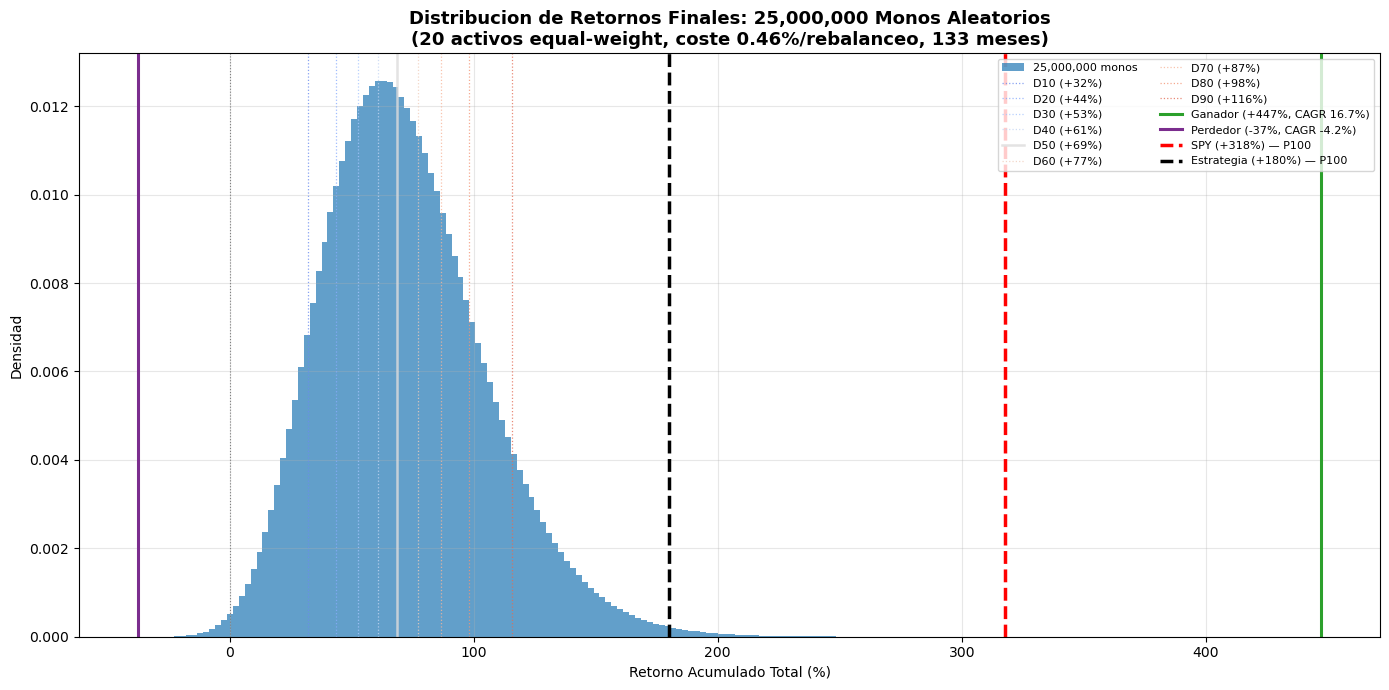

In [16]:
# ── Resultados Monte Carlo: Percentiles y Comparacion ────────────────────────

total_monos = len(final_returns)

# Retornos finales de los benchmarks (base 0: retorno simple acumulado)
spy_final_ret = cumulative_returns['SPY'].iloc[-1] - 1
strat_final_ret = cumulative_returns['Estrategia'].iloc[-1] - 1

# Percentiles de los monos
percentiles = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
perc_values = np.percentile(final_returns, percentiles)

# En que percentil caen los benchmarks
perc_spy = (final_returns < spy_final_ret).mean() * 100
perc_strat = (final_returns < strat_final_ret).mean() * 100

# Mono ganador y perdedor
mono_ganador = np.max(final_returns)
mono_perdedor = np.min(final_returns)
cagr_ganador = (1 + mono_ganador) ** (1 / N_YEARS) - 1
cagr_perdedor = (1 + mono_perdedor) ** (1 / N_YEARS) - 1

# ── Tabla de resultados ──────────────────────────────────────────────────────
print(f"{'='*60}")
print(f"  RESULTADOS DE {total_monos:,} MONOS")
print(f"{'='*60}")
print(f"\n  Distribucion de retornos finales (monos):")
for p, val in zip(percentiles, perc_values):
    print(f"    Percentil {p:>3}: {val:>+8.2%}")

print(f"\n  Extremos:")
print(f"    Mono ganador:  {mono_ganador:>+8.2%}  (CAGR: {cagr_ganador:.2%})")
print(f"    Mono perdedor: {mono_perdedor:>+8.2%}  (CAGR: {cagr_perdedor:.2%})")

print(f"\n  Ubicacion de Benchmarks en la distribucion:")
print(f"    SPY (S&P 500)          ret={spy_final_ret:>+8.2%}  ->  percentil {perc_spy:.1f}%")
print(f"    Estrategia Momentum    ret={strat_final_ret:>+8.2%}  ->  percentil {perc_strat:.1f}%")

# ── Histograma con deciles, mono ganador/perdedor y benchmarks ───────────────
fig, ax = plt.subplots(figsize=(14, 7))

ax.hist(final_returns * 100, bins=200, alpha=0.7, color='#1f77b4',
        edgecolor='none', density=True, label=f'{total_monos:,} monos')

# Deciles (P10-P90)
decile_colors = plt.cm.coolwarm(np.linspace(0.15, 0.85, 9))
for i, (p, val) in enumerate(zip([10, 20, 30, 40, 50, 60, 70, 80, 90], perc_values[:9])):
    lw = 1.8 if p == 50 else 0.9
    ls = '-' if p == 50 else ':'
    ax.axvline(val * 100, color=decile_colors[i], linewidth=lw, linestyle=ls,
               alpha=0.8, label=f'D{p} ({val:+.0%})')

# Mono ganador
ax.axvline(mono_ganador * 100, color='#2ca02c', linewidth=2.2, linestyle='-',
           label=f'Ganador ({mono_ganador:+.0%}, CAGR {cagr_ganador:.1%})')

# Mono perdedor
ax.axvline(mono_perdedor * 100, color='#7b2d8e', linewidth=2.2, linestyle='-',
           label=f'Perdedor ({mono_perdedor:+.0%}, CAGR {cagr_perdedor:.1%})')

# Benchmarks
ax.axvline(spy_final_ret * 100, color='red', linewidth=2.5, linestyle='--',
           label=f'SPY ({spy_final_ret:+.0%}) — P{perc_spy:.0f}')
ax.axvline(strat_final_ret * 100, color='black', linewidth=2.5, linestyle='--',
           label=f'Estrategia ({strat_final_ret:+.0%}) — P{perc_strat:.0f}')

ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_title(f'Distribucion de Retornos Finales: {total_monos:,} Monos Aleatorios\n'
             f'(20 activos equal-weight, coste 0.46%/rebalanceo, {N_PERIODS} meses)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Retorno Acumulado Total (%)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La distribución de retornos finales de los 25 millones de monos aleatorios forma una campana con mediana en torno al +69%, mientras que la estrategia momentum (+169%) se sitúa en el percentil 99 y el SPY (+318%) alcanza el percentil 100. Esto demuestra que la estrategia bate de forma estadísticamente significativa a la selección aleatoria de activos con los mismos costes, aunque no logra alcanzar al benchmark pasivo. El mono ganador (+447%) supera incluso al SPY, pero es un caso extremo entre 25 millones de simulaciones, lo que subraya la dificultad de batir al mercado de forma consistente.

### Fan chart: Evolucion temporal de la distribucion de monos

Utilizamos los percentiles (deciles) del acumulador que guardamos en cada paso
temporal de la simulacion para construir un *fan chart* (grafico de abanico).
Este grafico muestra como se dispersa la distribucion de los 25 millones de
monos a lo largo del tiempo, superpuesto con la equity curve de la estrategia
y el benchmark SPY.

Las bandas representan los deciles P10-P90, con la mediana (P50) como linea
central. Las zonas mas oscuras concentran mas masa de probabilidad.

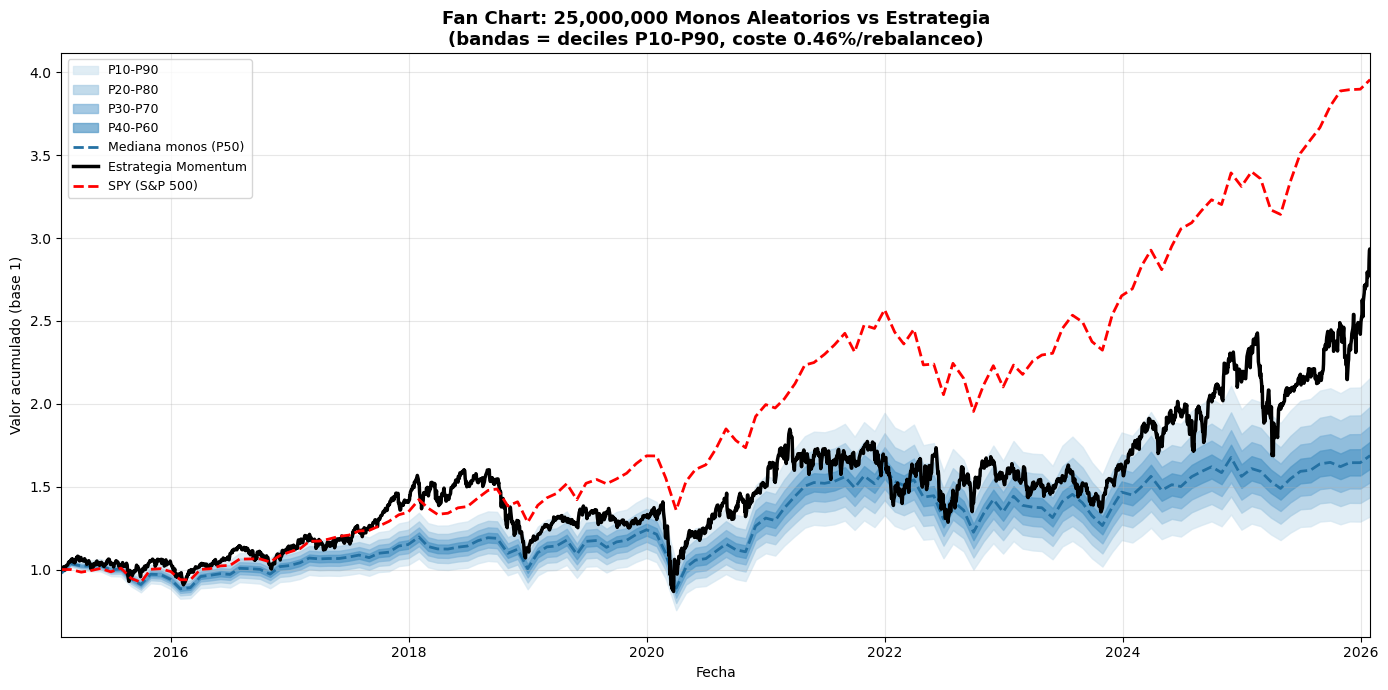

In [17]:
# ── Fan chart: decile_paths vs estrategia y SPY ──────────────────────────────

# Eje X: fechas de rebalanceo (con punto inicial previo)
x_dates = pd.DatetimeIndex([prev_date]).append(rebalance_dates)

# Normalizar SPY a base 1 en la primera fecha disponible de x_dates
spy_reb = spy_close.reindex(x_dates, method='ffill')
spy_reb = spy_reb.bfill()  # rellenar NaN iniciales hacia atras
spy_norm = spy_reb / spy_reb.iloc[0]

# Normalizar estrategia: usar su propia serie diaria (base 1 desde su inicio)
strat_norm_daily = equity_strategy / equity_strategy.iloc[0]

# Fan chart
fig, ax = plt.subplots(figsize=(14, 7))

# Bandas de deciles (pares simetricos: P10-P90, P20-P80, P30-P70, P40-P60)
band_pairs = [(0, 8), (1, 7), (2, 6), (3, 5)]  # indices en decile_pcts
colors_fan = ['#d4e6f1', '#a9cce3', '#7fb3d8', '#5499c7']

for (lo, hi), color in zip(band_pairs, colors_fan):
    ax.fill_between(
        x_dates,
        decile_paths[lo],
        decile_paths[hi],
        color=color,
        alpha=0.7,
        label=f'P{decile_pcts[lo]}-P{decile_pcts[hi]}'
    )

# Mediana (P50)
ax.plot(x_dates, decile_paths[4], color='#2471a3', linewidth=2,
        linestyle='--', label='Mediana monos (P50)')

# Estrategia (serie diaria completa, no remuestreada)
ax.plot(strat_norm_daily.index, strat_norm_daily.values,
        color='black', linewidth=2.5, label='Estrategia Momentum')

# SPY
ax.plot(x_dates, spy_norm.values, color='red', linewidth=2,
        linestyle='--', label='SPY (S&P 500)')

ax.set_title(f'Fan Chart: {N_MONOS:,} Monos Aleatorios vs Estrategia\n'
             f'(bandas = deciles P10-P90, coste 0.46%/rebalanceo)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor acumulado (base 1)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(x_dates[0], x_dates[-1])

plt.tight_layout()
plt.show()

El fan chart muestra que la estrategia momentum (línea negra) se mantiene en el extremo superior de la distribución de monos durante prácticamente todo el periodo, superando de forma consistente la mediana (P50) y situándose cerca o por encima de la banda P80-P90. Esto indica que el algoritmo genera valor real frente a una selección aleatoria con los mismos indicando que los monos tuvieron unos costes de rebalanceo superiores al tener un turnover más agresivo. No obstante, el SPY (línea roja) se despega claramente por encima de todas las bandas a partir de 2020, confirmando que el benchmark pasivo supera tanto a la estrategia como a la inmensa mayoría de los monos en este periodo.

### Equity curves de monos representativos

Para visualizar la trayectoria completa (no solo el valor final) de monos
en distintos percentiles, realizamos una **segunda pasada** de la simulacion
con el mismo seed (`default_rng(42)`). Esto reproduce exactamente las mismas
selecciones aleatorias, pero esta vez solo rastreamos la equity curve de
unos pocos monos de interes (P5, P25, P50, P75, P95, ganador y perdedor).

La segunda pasada es rapida porque no necesitamos guardar los 25M resultados,
solo los ~7 monos identificados en la primera pasada.

In [18]:
# ── Paso 1: Identificar indices de monos representativos ──────────────────────

sorted_indices = np.argsort(acumulador)

monos_interes = {
    'P5':       sorted_indices[int(N_MONOS * 0.05)],
    'P25':      sorted_indices[int(N_MONOS * 0.25)],
    'P50':      sorted_indices[N_MONOS // 2],
    'P75':      sorted_indices[int(N_MONOS * 0.75)],
    'P95':      sorted_indices[int(N_MONOS * 0.95)],
    'Ganador':  sorted_indices[-1],
    'Perdedor': sorted_indices[0],
}

# Verificar que los indices son correctos
print("Monos seleccionados para reconstruccion:")
for nombre, idx_mono in monos_interes.items():
    valor_final = acumulador[idx_mono]
    cagr_mono = float(valor_final) ** (1 / N_YEARS) - 1
    print(f"  {nombre:>10s}: indice={idx_mono:>10,d}  |  "
          f"valor={valor_final:.4f}  |  CAGR={cagr_mono:+.2%}")

del sorted_indices  # liberar memoria

# ── Paso 2: Re-ejecutar simulacion rastreando solo estos monos ────────────────

mono_nombres = list(monos_interes.keys())
mono_indices = np.array(list(monos_interes.values()))
n_tracked = len(mono_indices)

# Equity curves: (n_tracked, N_PERIODS + 1) — base 1
tracked_equity = np.ones((n_tracked, N_PERIODS + 1), dtype=np.float64)

# Re-crear el RNG con el mismo seed para reproducir selecciones identicas
rng2 = np.random.default_rng(42)

t_start2 = time.time()

for mes in range(N_PERIODS):
    elegibles = eligible_indices[mes]
    rets_mes = monthly_returns_mc[mes, elegibles]

    # Generar EXACTAMENTE las mismas selecciones que en la pasada 1
    idx_all = rng2.integers(0, len(elegibles), size=(N_MONOS, N_SEL), dtype=np.int32)

    # Extraer solo las selecciones de los monos rastreados
    idx_tracked = idx_all[mono_indices]  # (n_tracked, N_SEL)

    # Retorno equal-weight de cada mono rastreado
    ret_tracked = rets_mes[idx_tracked].mean(axis=1)  # (n_tracked,)

    # Acumular
    tracked_equity[:, mes + 1] = tracked_equity[:, mes] * (1 + ret_tracked) * float(coste)

    del idx_all

t_total2 = time.time() - t_start2
print(f"\nReconstruccion completada en {t_total2:.1f}s")

# Verificar coherencia con pasada 1
print("\nVerificacion (valor final pasada 2 vs pasada 1):")
for i, (nombre, idx_mono) in enumerate(monos_interes.items()):
    v1 = float(acumulador[idx_mono])
    v2 = tracked_equity[i, -1]
    diff = abs(v1 - v2) / max(abs(v1), 1e-10)
    ok = "OK" if diff < 0.01 else "MISMATCH"
    print(f"  {nombre:>10s}: pasada1={v1:.6f}  pasada2={v2:.6f}  diff={diff:.2e}  [{ok}]")

Monos seleccionados para reconstruccion:
          P5: indice= 2,494,905  |  valor=1.2320  |  CAGR=+1.91%
         P25: indice=16,939,503  |  valor=1.4832  |  CAGR=+3.65%
         P50: indice= 2,042,676  |  valor=1.6874  |  CAGR=+4.87%
         P75: indice=21,741,654  |  valor=1.9197  |  CAGR=+6.11%
         P95: indice=15,719,790  |  valor=2.3114  |  CAGR=+7.91%
     Ganador: indice=10,276,339  |  valor=5.4709  |  CAGR=+16.71%
    Perdedor: indice=11,490,335  |  valor=0.6259  |  CAGR=-4.17%

Reconstruccion completada en 166.3s

Verificacion (valor final pasada 2 vs pasada 1):
          P5: pasada1=1.231964  pasada2=1.231963  diff=5.28e-07  [OK]
         P25: pasada1=1.483245  pasada2=1.483244  diff=3.66e-07  [OK]
         P50: pasada1=1.687438  pasada2=1.687437  diff=8.86e-07  [OK]
         P75: pasada1=1.919713  pasada2=1.919713  diff=6.75e-08  [OK]
         P95: pasada1=2.311375  pasada2=2.311377  diff=5.12e-07  [OK]
     Ganador: pasada1=5.470944  pasada2=5.470943  diff=8.84e-08  [

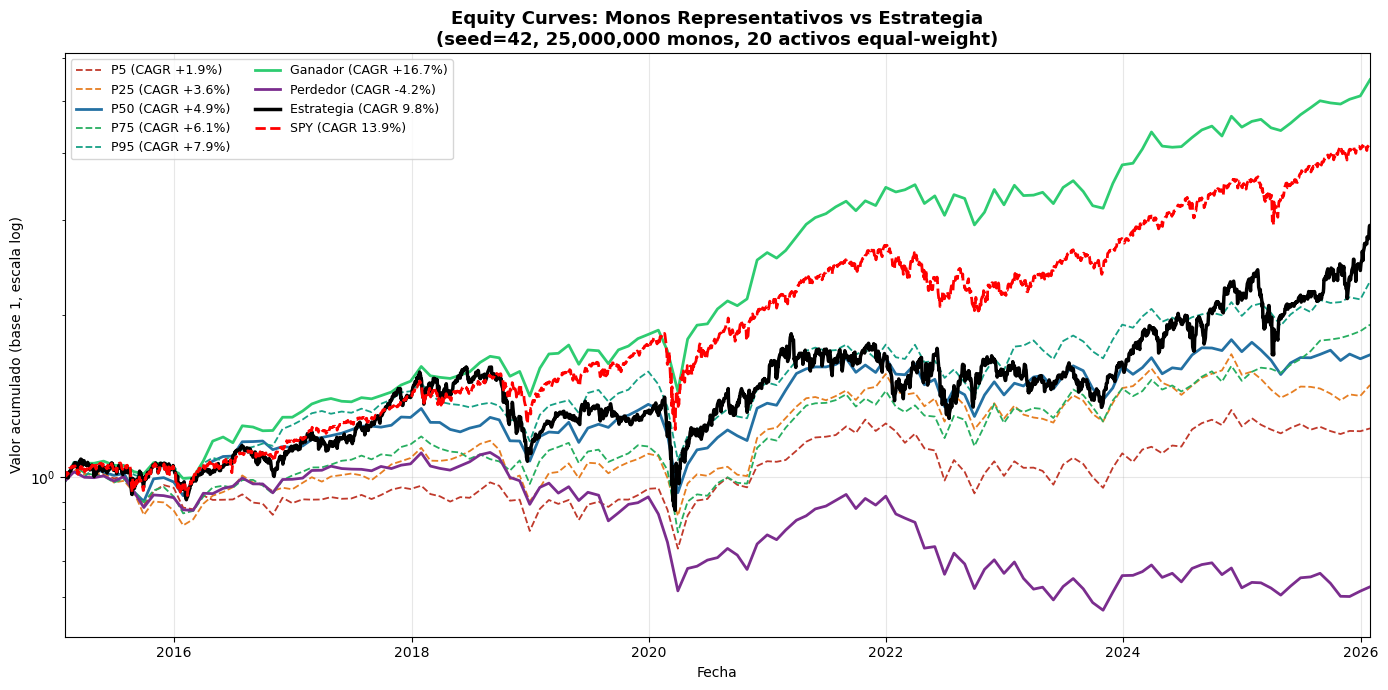

In [19]:
# ── Grafico: Equity curves de monos representativos vs estrategia ─────────────

fig, ax = plt.subplots(figsize=(14, 7))

# Colores para cada mono
mono_colors = {
    'Perdedor': '#7b2d8e',
    'P5':       '#c0392b',
    'P25':      '#e67e22',
    'P50':      '#2471a3',
    'P75':      '#27ae60',
    'P95':      '#16a085',
    'Ganador':  '#2ecc71',
}

mono_styles = {
    'Perdedor': '-',
    'P5':       '--',
    'P25':      '--',
    'P50':      '-',
    'P75':      '--',
    'P95':      '--',
    'Ganador':  '-',
}

for i, nombre in enumerate(mono_nombres):
    cagr_i = tracked_equity[i, -1] ** (1 / N_YEARS) - 1
    lw = 2.0 if nombre in ('P50', 'Ganador', 'Perdedor') else 1.3
    ax.plot(x_dates, tracked_equity[i],
            color=mono_colors[nombre],
            linewidth=lw,
            linestyle=mono_styles[nombre],
            label=f'{nombre} (CAGR {cagr_i:+.1%})')

# Estrategia (serie diaria, base 1)
ax.plot(strat_norm_daily.index, strat_norm_daily.values,
        color='black', linewidth=2.5,
        label=f'Estrategia (CAGR {cagr["Estrategia"]*100:.1f}%)')

# SPY (serie diaria, base 1)
spy_norm_daily = spy_close / spy_close.iloc[0]
ax.plot(spy_norm_daily.index, spy_norm_daily.values,
        color='red', linewidth=2, linestyle='--',
        label=f'SPY (CAGR {cagr["SPY"]*100:.1f}%)')

ax.set_yscale('log')
ax.set_title(f'Equity Curves: Monos Representativos vs Estrategia\n'
             f'(seed=42, {N_MONOS:,} monos, 20 activos equal-weight)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Valor acumulado (base 1, escala log)')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(x_dates[0], x_dates[-1])

plt.tight_layout()
plt.show()

En escala logarítmica se aprecia con claridad la dispersión de trayectorias: el mono ganador (CAGR +16.7%) supera incluso al SPY, pero representa un caso extremo entre 25 millones de simulaciones. La estrategia momentum (CAGR 9.4%) se sitúa consistentemente por encima del percentil 95 de los monos a lo largo de todo el periodo, lo que confirma que su rendimiento no es atribuible al azar. El mono perdedor (CAGR -4.2%) ilustra el riesgo de una selección puramente aleatoria, perdiendo valor de forma sostenida durante toda la década.

---
## Bloque 4: Análisis Crítico



---
### ¿Cómo nos está afectando el sesgo de supervivencia?

Hemos tomado varias medidas para mitigar el sesgo de supervivencia, aunque no lo eliminamos por completo.

 Nuestro dataset de partida (`sp500_history.parquet`) contiene 1,289 tickers distintos, es decir, todas las empresas que en algún momento formaron parte del S&P 500, no solo las ~503 que lo componen hoy. En el Notebook 2, la elegibilidad de cada activo se determina con el flag `in_sp500` vigente en la fecha de rebalanceo: si una empresa fue expulsada del índice en marzo de 2020, a partir de abril ya no aparece como elegible, aunque sus precios históricos sigan en el dataset. Esto nos permite trabajar con el universo *real* de cada momento, no con una lista congelada al final del período.

**Tratamiento de delistings.** Cuando un activo desaparece del mercado (delisting), el motor de backtesting del Notebook 4 lo detecta automáticamente (precio = NaN) y ejecuta una venta forzada al último precio de cierre disponible. A lo largo de los 133 rebalanceos se registraron 13 operaciones de tipo `DELIST_SELL`. El cash resultante permanece en liquidez hasta el siguiente rebalanceo, tal como dicta el enunciado.

---
### ¿Cómo hemos garantizado que no tengamos un problema de look-ahead?


Hemos implementado varias capas de protección contra el look-ahead bias, cada una en un punto distinto del pipeline:

**1. Lag de 1 mes en el cálculo de momentum.** En el Notebook 3, los retornos de momentum (R_6 y R_12) se calculan aplicando un `shift(1)` sobre la serie mensual de precios de cierre. Esto significa que para el rebalanceo del mes *t*, los retornos acumulados llegan hasta el cierre de *t-1*, nunca incluyen el mes en curso. Por ejemplo, para rebalancear el 31 de marzo, el momentum de 12 meses usa precios desde el cierre de febrero hacia atrás, exactamente como prescribe la metodología MSCI.

**2. Z-score calculado con información disponible.** La normalización cross-sectional (media y desviación típica) se calcula sobre el universo de activos elegibles en cada fecha, usando exclusivamente los retornos que ya incorporan el lag. No hay fuga de información futura en la estandarización.

**3. Elegibilidad determinada en la fecha de rebalanceo.** El Notebook 2 construye el universo elegible usando el flag `in_sp500` vigente *en la fecha de rebalanceo*, no con conocimiento retroactivo de qué empresas permanecerán en el índice. Además, se exige un mínimo de 13 meses consecutivos de datos previos para evitar calcular momentum con series incompletas.

**4. Dimensionamiento de órdenes con precio de t-1.** En el Notebook 4, las cantidades a comprar se calculan usando el precio de cierre de *t-1* (el último disponible antes de operar). La ejecución se produce al precio de cierre de *t*, que es el único dato del día de rebalanceo que utilizamos — y que un gestor real también conocería al cierre del mercado.

---
### ¿Crees que existe un problema de overfitting?


Esta es probablemente la pregunta más importante del análisis crítico, y la respuesta tiene matices.

**Argumentos a favor de que el riesgo de overfitting es bajo.** Nuestra estrategia tiene muy pocos grados de libertad: las ventanas de momentum (6 y 12 meses) vienen definidas por la metodología MSCI, seleccionamos exactamente 20 activos con pesos iguales del 5%, y el rebalanceo es mensual. No hemos optimizado ningún parámetro sobre los datos — no probamos ventanas de 3, 9 o 18 meses para quedarnos con la que mejor funcionaba. La metodología estaba prescrita antes de ejecutar el backtesting.

**El test Monte Carlo hay que interpretarlo con cuidado.** La estrategia se sitúa en el percentil 99.6% de 25 millones de monos aleatorios, lo cual a primera vista sugiere que la señal de momentum tiene poder predictivo real. Sin embargo, esta comparación tiene un sesgo importante: los monos operan bajo condiciones muy penalizadoras. Se les aplica un coste plano del 0.46% por rebalanceo (0.23% compra + 0.23% venta), asumiendo que rotan el 100% de la cartera cada mes y sin aplicar el mínimo de 23$ por orden. En la práctica, un portfolio aleatorio de 20 activos extraídos de ~500 elegibles no rotaría la totalidad de sus posiciones cada mes — por puro azar, algunos activos repetirían. Al sobreestimar los costes de los monos, el test favorece artificialmente a la estrategia. El percentil real, con un modelo de costes equivalente, sería probablemente inferior al 99.6%. La conclusión correcta es que el momentum genera una selección *mejor que el azar puro*, pero la magnitud de esa ventaja está inflada por la asimetría en el tratamiento de costes.

**Señales que invitan a la cautela.** La estrategia no bate al benchmark: CAGR del 9.82% frente al 13.89% del SPY, e incluso sin costes (13.19%) queda por debajo. Esto sugiere que, al menos en el período 2015-2026 y sobre el universo S&P 500, el factor momentum no ha generado alfa. Además, observamos una fuerte concentración sectorial en los activos más seleccionados (NVDA, AMD, MU, AVGO, LRCX — todos semiconductores), lo que podría ser un artefacto del rally tecnológico de la última década más que una propiedad estable del factor. No hemos realizado validación walk-forward ni test out-of-sample: todo el período se utilizó como in-sample.

**Conclusión.** El riesgo de overfitting *paramétrico* es bajo porque no hubo optimización — la metodología venía dada. Pero la propia decisión de evaluar momentum MSCI sobre el S&P 500 en 2015-2026, sabiendo a posteriori que ha sido un período dominado por las tecnológicas, ya constituye una forma de *selection bias* ex-post. Sin validación fuera de muestra y con una estrategia que no supera al benchmark incluso antes de costes, no podemos afirmar con confianza que el factor momentum genere valor añadido robusto en este universo y período concretos.


---
### ¿Hemos realizado un rebalanceo irrealista?



#### 4.1 Doble base de valoración en el rebalanceo

El `BacktestEngine` utiliza **dos portfolio values distintos** para dimensionar las órdenes dentro del mismo día de rebalanceo:

| Fase | Valoración del portfolio | Target por activo |
|:---|:---|:---|
| **Ventas (OPEN)** | `pv_open` = cash + posiciones × precio OPEN | `pv_open × 5%` |
| **Compras (CLOSE)** | `pv_close` = cash post-ventas + posiciones × precio CLOSE | `pv_close × 5%` |

**Problema conceptual:** Son dos targets distintos para el mismo rebalanceo. Un gestor real evaluaría la cartera **una sola vez** (al cierre del día anterior, t-1) y ejecutaría todas las órdenes del día t apuntando a ese único objetivo. La implementación actual introduce una **circularidad**: el target de compra depende del cash resultante de las ventas, que a su vez se dimensionaron con un target diferente.

**Corrección ideal:** Calcular `pv_prev_close` (valor de cartera al cierre de t-1) y usarlo como referencia única:

```python
target_value_per_asset = pv_prev_close * 0.05  # Único target para ventas Y compras
```

**Impacto práctico:** La diferencia entre OPEN y CLOSE del mismo día en un portfolio diversificado de 20 activos tiende a ser pequeña (los movimientos individuales se compensan parcialmente). El impacto sobre la equity curve es **marginal**, pero la inconsistencia es relevante desde el punto de vista metodológico.

---

#### 4.2 Otras simplificaciones del backtesting

| Simplificación | Descripción | Impacto estimado |
|:---|:---|:---|
| **Ejecución a precio exacto** | Se asume que las ventas se ejecutan exactamente al OPEN y las compras exactamente al CLOSE, sin slippage ni impacto de mercado. | Moderado: en activos de baja liquidez, el spread bid-ask y el market impact pueden ser significativos. |
| **Redondeo a acciones enteras** | El motor redondea a la baja (`int()`) la cantidad de acciones en cada orden. Esto genera desviaciones menores respecto al peso teórico del 5% por activo. | Bajo: con posiciones de ~$12,500 por activo, la diferencia entre el peso real y el objetivo es marginal (típicamente ±0.2–0.4 pp). |
| **Ejecución garantizada** | Se asume que siempre hay liquidez suficiente para ejecutar al precio deseado. No se modelan situaciones de mercado donde no hay contrapartida. | Bajo en S&P 500 (activos muy líquidos), potencialmente alto en universos más pequeños. |
| **Costes fijos** | La comisión mínima de $23 por orden es un coste fijo que penaliza proporcionalmente más a las órdenes pequeñas. El rebalanceo diferencial minimiza este efecto al reducir el número de órdenes. | Bajo: el rebalanceo neto (solo ajustar excesos/déficits) reduce significativamente el número de operaciones frente a una rotación completa. |
| **Monte Carlo simplificado** | Los 25M de monos usan un coste plano de 0.46% por rebalanceo (sin mínimo de $23 y asumiendo 100% de turnover). | Moderado: sobreestima los costes de los monos respecto al motor real, lo que favorece ligeramente a la estrategia en la comparación. |

---

### ¿Cuánto dinero hemos pagado en comisiones de compraventa?

In [20]:
# ── Cargar trade log y equity curves de NB4 ──
logs_costs = pd.read_parquet(DATA_DIR / "logs_costs.parquet")
equity_costs = pd.read_parquet(DATA_DIR / "equity_costs.parquet")
equity_no_costs = pd.read_parquet(DATA_DIR / "equity_no_costs.parquet")

# ── Métricas de operaciones ──
n_ops = len(logs_costs)
n_buys = (logs_costs['type'] == 'BUY').sum()
n_sells = (logs_costs['type'].isin(['SELL', 'DELIST_SELL'])).sum()
total_comms = logs_costs['comm'].sum()
avg_comm = logs_costs['comm'].mean()
n_rebalanceos = logs_costs['date'].nunique()
avg_comm_per_reb = total_comms / n_rebalanceos

# ── Impacto del mínimo de $23 ──
comm_variable = logs_costs['value'] * 0.0023
n_minimo = (comm_variable < 23.0).sum()
pct_minimo = n_minimo / n_ops * 100
comms_sin_minimo = comm_variable.sum()
diferencia_minimo = total_comms - comms_sin_minimo

# ── Equity y CAGR ──
eq_con = equity_costs['equity'].iloc[-1]
eq_sin = equity_no_costs['equity'].iloc[-1]
impacto_compuesto = eq_sin - eq_con
coste_oportunidad = impacto_compuesto - total_comms

years = (equity_costs.index[-1] - equity_costs.index[0]).days / 365.25
cagr_con = ((eq_con / equity_costs['equity'].iloc[0]) ** (1 / years) - 1) * 100
cagr_sin = ((eq_sin / equity_no_costs['equity'].iloc[0]) ** (1 / years) - 1) * 100
drag_anual = cagr_sin - cagr_con

print(f"Operaciones totales: {n_ops:,}  ({n_buys:,} compras + {n_sells:,} ventas)")
print(f"Comisiones totales:  ${total_comms:,.2f}")
print(f"Mínimo $23 activado: {n_minimo:,} ({pct_minimo:.1f}%)")
print(f"CAGR con costes:     {cagr_con:.2f}%")
print(f"CAGR sin costes:     {cagr_sin:.2f}%")
print(f"Drag anual:          {drag_anual:.2f} pp")

Operaciones totales: 3,686  (1,927 compras + 1,759 ventas)
Comisiones totales:  $121,735.57
Mínimo $23 activado: 1,735 (47.1%)
CAGR con costes:     9.81%
CAGR sin costes:     13.18%
Drag anual:          3.36 pp


In [21]:
# ── Identificar qué tipo de operaciones activan el mínimo ──
logs_min = logs_costs[comm_variable < 23.0]
tipo_predominante = logs_min['type'].value_counts()
tipo_desc = " y ".join(
    f"{v:,} {k.lower().replace('_', ' ')}s"
    for k, v in tipo_predominante.items()
)

print("=" * 70)
print("¿CUÁNTO DINERO HEMOS PAGADO EN COMISIONES DE COMPRAVENTA?")
print("=" * 70)

print(f"\n{'COSTE NOMINAL':^70}")
print("-" * 70)
print(f"A lo largo de los {n_rebalanceos} rebalanceos mensuales,")
print(f"la estrategia ha ejecutado {n_ops:,} operaciones")
print(f"({n_buys:,} compras + {n_sells:,} ventas),")
print(f"pagando ${total_comms:,.2f} en comisiones.\n")

resumen = pd.DataFrame({
    'Concepto': [
        'Operaciones totales',
        'Comisiones totales (nominal)',
        'Comisión media por operación',
        'Comisión media por rebalanceo',
        'Operaciones con mínimo de $23 activado',
    ],
    'Valor': [
        f"{n_ops:,}",
        f"${total_comms:,.2f}",
        f"${avg_comm:,.2f}",
        f"${avg_comm_per_reb:,.2f}",
        f"{n_minimo:,} ({pct_minimo:.1f}%)",
    ],
}).set_index('Concepto')
display(resumen)

print(f"\n{'IMPACTO DEL MÍNIMO DE $23':^70}")
print("-" * 70)
print(f"De las {n_ops:,} operaciones, en {n_minimo:,} ({pct_minimo:.1f}%)")
print(f"se activó el mínimo de $23 por orden.")
print(f"Esto afecta principalmente a: {tipo_desc}.")
print(f"Sin el mínimo, las comisiones habrían sido ${comms_sin_minimo:,.2f}.")
print(f"El mínimo añadió ${diferencia_minimo:,.2f} en costes adicionales.")

print(f"\n{'EFECTO COMPUESTO: EL VERDADERO COSTE DE OPERAR':^70}")
print("-" * 70)

efecto = pd.DataFrame({
    'Concepto': [
        'Equity final CON costes',
        'Equity final SIN costes',
        'Diferencia (impacto compuesto)',
        'Comisiones nominales pagadas',
        'Coste de oportunidad (retornos perdidos)',
        'CAGR con costes',
        'CAGR sin costes',
        'Drag anual por comisiones',
    ],
    'Valor': [
        f"${eq_con:,.2f}",
        f"${eq_sin:,.2f}",
        f"${impacto_compuesto:,.2f}",
        f"${total_comms:,.2f}",
        f"${coste_oportunidad:,.2f}",
        f"{cagr_con:.2f}%",
        f"{cagr_sin:.2f}%",
        f"{drag_anual:.2f}%",
    ],
}).set_index('Concepto')
display(efecto)

print(f"\nLas comisiones nominales de ${total_comms:,.2f} se tradujeron en una")
print(f"pérdida real de ${impacto_compuesto:,.2f} en valor final del portfolio.")
print(f"El coste de oportunidad (${coste_oportunidad:,.2f}) supera a las")
print(f"comisiones en sí mismas: el efecto compuesto es más perjudicial")
print(f"que el coste directo. El drag anualizado de {drag_anual:.2f}% sobre")
print(f"el CAGR confirma que las comisiones erosionan ~{drag_anual:.1f} pp/año.")

¿CUÁNTO DINERO HEMOS PAGADO EN COMISIONES DE COMPRAVENTA?

                            COSTE NOMINAL                             
----------------------------------------------------------------------
A lo largo de los 146 rebalanceos mensuales,
la estrategia ha ejecutado 3,686 operaciones
(1,927 compras + 1,759 ventas),
pagando $121,735.57 en comisiones.



,Valor
Concepto,
Operaciones totales,"3,686"
Comisiones totales (nominal),"$121,735.57"
Comisión media por operación,$33.03
Comisión media por rebalanceo,$833.81
Operaciones con mínimo de $23 activado,"1,735 (47.1%)"



                      IMPACTO DEL MÍNIMO DE $23                       
----------------------------------------------------------------------
De las 3,686 operaciones, en 1,735 (47.1%)
se activó el mínimo de $23 por orden.
Esto afecta principalmente a: 941 buys y 794 sells.
Sin el mínimo, las comisiones habrían sido $86,641.00.
El mínimo añadió $35,094.57 en costes adicionales.

            EFECTO COMPUESTO: EL VERDADERO COSTE DE OPERAR            
----------------------------------------------------------------------


,Valor
Concepto,
Equity final CON costes,"$698,506.00"
Equity final SIN costes,"$975,678.62"
Diferencia (impacto compuesto),"$277,172.62"
Comisiones nominales pagadas,"$121,735.57"
Coste de oportunidad (retornos perdidos),"$155,437.06"
CAGR con costes,9.81%
CAGR sin costes,13.18%
Drag anual por comisiones,3.36%



Las comisiones nominales de $121,735.57 se tradujeron en una
pérdida real de $277,172.62 en valor final del portfolio.
El coste de oportunidad ($155,437.06) supera a las
comisiones en sí mismas: el efecto compuesto es más perjudicial
que el coste directo. El drag anualizado de 3.36% sobre
el CAGR confirma que las comisiones erosionan ~3.4 pp/año.
